In [11]:
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

In [12]:
df = pd.read_csv("data/anderson_lab_protist_data.csv")

df.dtypes

number.bottles       int64
media                  str
productivity       float64
year                 int64
prey                   str
predator               str
day                  int64
bottle                 str
structure              str
network.syn.lap    float64
bottle.number        int64
replicate              str
connectivity         int64
nghbr.connect      float64
pred.density       float64
prey.density       float64
ln.pred            float64
ln.prey            float64
pred.oc              int64
prey.oc              int64
volume.L           float64
dtype: object

<Axes: xlabel='prey.density', ylabel='pred.density'>

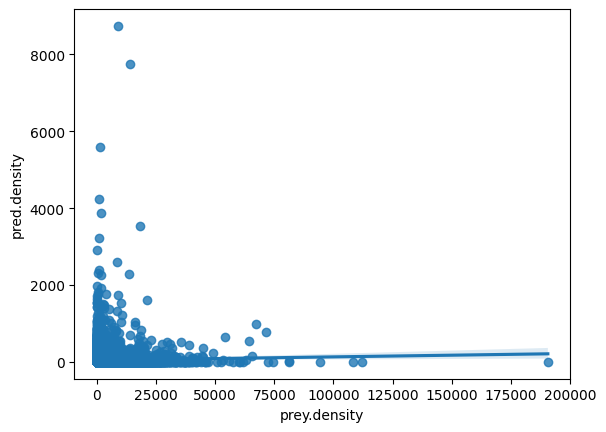

In [13]:
sns.regplot(data=df, y="pred.density", x="prey.density")

In [14]:
model = RandomForestRegressor(random_state=42)

X = df.select_dtypes(include=[np.number]).drop(columns=['prey.density'])
y = df['prey.density']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model.fit(X_train, y_train)

predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)

print(mse, df['prey.density'].var()**(1/2))

1958.6896768490212 5125.080729325878


In [15]:
df.groupby("structure")[['pred.density', 'prey.density']].describe()

pred.density                                    \
                                   count        mean         std  min  25%   
structure                                                                    
dendritic                         6044.0   52.879089  171.126864  0.0  0.0   
high.asynchrony.high.asynch       1392.0    0.803966    7.181809  0.0  0.0   
high.asynchrony.low.asy           1376.0    0.475838    2.683929  0.0  0.0   
isolated                           316.0  164.546179  521.370093  0.0  0.0   
lattice                           6044.0   65.113142  183.725943  0.0  0.0   
low.asynchrony                    1376.0    0.623409    4.247338  0.0  0.0   
straight                          1904.0   29.080615   93.053478  0.0  0.0   

                                                                prey.density  \
                                   50%         75%          max        count   
structure                                                                      
dendritic                     0.000000   43.487721  5595.121951       6044.0   
high.asynchrony.high.asynch   0.000000    0.000000   161.490683       1392.0   
high.asynchrony.low.asy       0.000000    0.000000    32.154341       1376.0   
isolated                     14.860590  208.238451  7748.444938        316.0   
lattice                       4.864997   86.967647  8739.884393       6044.0   
low.asynchrony                0.000000    0.000000    67.811935       1376.0   
straight                      0.000000    4.535150   862.250263       1904.0   

                                                                       \
                                    mean          std  min        25%   
structure                                                               
dendritic                    2551.914720  6217.713109  0.0   4.961549   
high.asynchrony.high.asynch    59.865753   129.213503  0.0   0.000000   
high.asynchrony.low.asy        68.076668   153.156175  0.0   0.000000   
isolated                     2701.846819  5695.838148  0.0  16.746864   
lattice                      2596.808137  5884.465671  0.0   0.000000   
low.asynchrony                 97.781006   179.763495  0.0   0.000000   
straight                      488.981219  2093.050390  0.0   0.000000   

                                                                     
                                    50%          75%            max  
structure                                                            
dendritic                    144.404371  2772.525171  190625.000000  
high.asynchrony.high.asynch    3.126125    57.832845    1512.756019  
high.asynchrony.low.asy        3.852085    62.064628    1582.914573  
isolated                     104.010989  2703.422554   40620.689660  
lattice                      106.502376  3021.681556  108385.714300  
low.asynchrony                11.987126   126.370154    1802.641803  
straight                       5.173311    44.714944   43846.153850